# Homework 4

## Part a

Using a subset of the IMDB database (only the first 7000 words) we are going to make a model and plot the accuracy.  The model will have two layers of 16 neurons each, with a final layer of one neuron.  Using the model shown below, run it and plot the training loss and accuracy, and the validation loss and accuracy.  Use rmsprop optimizer, batch size = 512, twenty epochs and a 60/40 train/validation split.

In [2]:
from tensorflow.keras.datasets import imdb
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import gc
#######################################################
# reduced number of words to 7000, from 10000, to speed training
# (train_data, train_labels), _ = imdb.load_data(num_words=10000)
# changed vectorize_squences to 5000 as well
# def vectorize_sequences(sequences, dimension=10000):

(train_data, train_labels), _ = imdb.load_data(num_words=7000)

def vectorize_sequences(sequences, dimension=7000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.
    return results
train_data = vectorize_sequences(train_data)


In [ ]:
model = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
# add the compile and fit below

In [ ]:
# code to plot the loss and accuracy goes here

# Part b

This model appears to be overfitting.  Create a model with fewer neurons and see if that fixes overfitting.  Still run it out to 20 epochs.  Plot the loss and accuracy.

# Part c

Go back to the original model, but use L1 regularization to see if that improves the model.  Plot loss and accuracy.  Use an L1 regularization penalty of 0.002.

# Part d

Same as above, but use L2 regularization.  Use an L2 regularization penalty of 0.002.  Plot the loss and accuracy.

# Part e

Create an elastic net model (L1 and L2 regularization) using the same number of neurons and layers as above.  Use an L1 and L2 regularization penalty of 0.001.  Use lambda 0.001 for both.  Plot the loss and accuracy.

# Part f

Use the model from part a and set 50% droputs between the layers.  Plot the loss and accuracy.

# Part g

Setup the model from part a, but use a variable learning rate.  Use the lr_schedule setup below for your learing rate.  Plot the loss and accuracy.

In [16]:
N_TRAIN = int(len(train_data) * 0.6)  # size of training data with 60/40% validation split
BATCH_SIZE = 512
STEPS_PER_EPOCH = N_TRAIN//BATCH_SIZE

lr_schedule = tf.keras.optimizers.schedules.InverseTimeDecay(
  0.01,
  decay_steps=STEPS_PER_EPOCH*5,
  decay_rate=1,
  staircase=False)


This graph shows the variable learning rate at each epoch

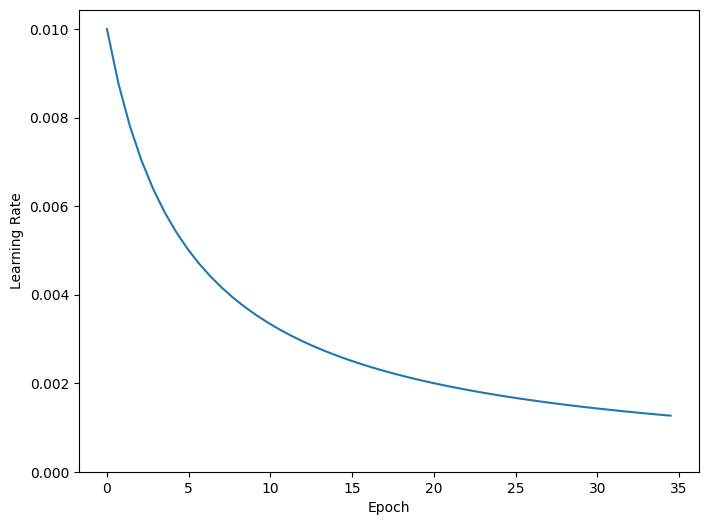

In [17]:
step = np.linspace(0,1000)
lr = lr_schedule(step)
plt.figure(figsize = (8,6))
plt.plot(step/STEPS_PER_EPOCH, lr)
plt.ylim([0,max(plt.ylim())])
plt.xlabel('Epoch')
_ = plt.ylabel('Learning Rate')

# Part h

Plot the validation accuracy of all the different models on a single plot with a legend.  Next, plot the validation loss of all the models on a single plot with a legend.

# Part i

Use any combination of the techniques above (more or less neurons, regularization, learning rate, dropout, and any changes to hyperparameters) to create the best validation accuracy model you can.  You must create at least 5 different models.  The final model must be better than any of the models above for full credit.